In [ ]:
# # A/B Testing: Layman's Explanation
# # Imagine you run a small online store and want to know whether a new product description or a different website design 
#leads to more sales.
# You have two options:

# # Option A: Keep the current website and description as it is.
# # Option B: Change the description or design and see if it performs better.
# # To figure out which option is better, you split your visitors into two random groups.
# One group sees Option A (the original), and the other sees Option B (the new version). 
# After running the test for a while, you compare the results (like how many people made a purchase from each group) to see which version performed better.

# # This process of comparing two versions to determine which one works better is called A/B testing.
# It's like running an experiment where you change one thing at a time to see if it has an impact.

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Simulate visitors and purchases for two groups
np.random.seed(42)  # For reproducibility

# Group A: 1000 visitors, 5% conversion rate
group_a_visitors = 1000
group_a_conversion_rate = 0.05
group_a_purchases = np.random.binomial(group_a_visitors, group_a_conversion_rate)

# Group B: 1000 visitors, 6% conversion rate
group_b_visitors = 1000
group_b_conversion_rate = 0.06
group_b_purchases = np.random.binomial(group_b_visitors, group_b_conversion_rate)

# Print out the results
print(f"Group A: {group_a_purchases} purchases out of {group_a_visitors} visitors")
print(f"Group B: {group_b_purchases} purchases out of {group_b_visitors} visitors")

# Now, calculate the conversion rate for each group
group_a_rate = group_a_purchases / group_a_visitors
group_b_rate = group_b_purchases / group_b_visitors

print(f"Group A Conversion Rate: {group_a_rate * 100:.2f}%")
print(f"Group B Conversion Rate: {group_b_rate * 100:.2f}%")


Group A: 49 purchases out of 1000 visitors
Group B: 62 purchases out of 1000 visitors
Group A Conversion Rate: 4.90%
Group B Conversion Rate: 6.20%


In [ ]:
# Hypothesis Testing: An Overview
# Hypothesis testing is a statistical method used to make inferences or draw 
# conclusions about a population based on sample data. It involves testing an assumption or claim about a population parameter.

# Key Concepts
# Null Hypothesis (H₀): This is the statement that there is no effect, difference, or relationship in the population. 
# It's the hypothesis you are trying to test against.
# Example: "There is no difference in the average heights of men and women."
# Alternative Hypothesis (H₁ or Ha): This is the opposite of the null hypothesis, suggesting that there is an effect, 
# difference, or relationship.
# Example: "There is a difference in the average heights of men and women."
# Test Statistic: This is a value that is calculated from the sample data and is used to determine whether to reject 
# the null hypothesis. The type of test statistic depends on the test you are performing (e.g., t-test, z-test).
# P-value: The probability of obtaining a test statistic at least as extreme as the one observed, assuming the null
# hypothesis is true. A smaller p-value suggests stronger evidence against the null hypothesis.
# If the p-value is less than or equal to the significance level (often 0.05), we reject the null hypothesis.
# If the p-value is greater than the significance level, we fail to reject the null hypothesis.
# Significance Level (α): This is the threshold probability used to determine whether the p-value is small enough 
# to reject the null hypothesis. Commonly, α is set at 0.05.
# Type I Error: Occurs when the null hypothesis is rejected when it is actually true (false positive).
# Type II Error: Occurs when the null hypothesis is not rejected when it is actually false (false negative).
# Steps in Hypothesis Testing
# State the hypotheses:
# Null Hypothesis (H₀)
# Alternative Hypothesis (H₁)
# Choose a significance level (α): Often set to 0.05.
# Select the appropriate test: Depending on the type of data, you may choose a t-test, z-test, chi-square test, etc.
# Calculate the test statistic: Use sample data to calculate the test statistic (e.g., t-value, z-value).
# Make a decision: Compare the p-value with the significance level α.
# If p-value ≤ α, reject the null hypothesis.
# If p-value > α, fail to reject the null hypothesis.
# Draw a conclusion: Based on the results, interpret the statistical findings in the context of the research.

In [2]:
import numpy as np
from scipy import stats

# Given data
sample_mean = 162  # Sample mean height
population_mean = 160  # Hypothesized population mean height
sample_std = 10  # Sample standard deviation
n = 30  # Sample size

# Calculate the t-statistic
t_statistic = (sample_mean - population_mean) / (sample_std / np.sqrt(n))

# Degrees of freedom
df = n - 1

# Calculate the p-value for a two-tailed test
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

# Output results
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision based on p-value
if p_value <= 0.05:
    print("Reject the null hypothesis. There is a significant difference in mean height.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in mean height.")


T-statistic: 1.0954
P-value: 0.2823
Fail to reject the null hypothesis. There is no significant difference in mean height.


In [ ]:
# Resampling in Statistics
# Resampling is a powerful statistical technique that involves repeatedly drawing samples from a dataset to make inferences about a population. It's often used when traditional parametric assumptions (like the normality of data) can't be made, or when an analytical solution is difficult or impossible to derive. Resampling methods allow for more flexible and robust inferences in statistical analysis.

# Two common types of resampling are:

# Bootstrap Resampling
# Permutation (or Randomization) Resampling


In [ ]:
# 1. Bootstrap Resampling
# Bootstrap is a technique used to estimate the sampling distribution of a statistic (like the mean, median, or standard deviation) by drawing repeated samples with replacement from the original dataset. The goal is to understand the variability of a statistic without needing to make strong assumptions about the data's distribution.

# Key Concepts:

# With replacement: Each time a sample is drawn, it’s put back into the original dataset, so the same data point can be chosen more than once.
# Resampling: This process of drawing repeated samples is done several times, often thousands of times, to create many "bootstrap" samples.
# Statistic estimation: After resampling, you calculate the statistic of interest (mean, median, etc.) for each resample.
# Example: Bootstrap to Estimate the Mean and Confidence Interval

# Suppose you have a sample dataset of 10 observations, and you want to estimate the mean and calculate the 95% confidence interval using the bootstrap method.

Original Mean: 11.5
Bootstrap 95% Confidence Interval: (9.7, 13.3)


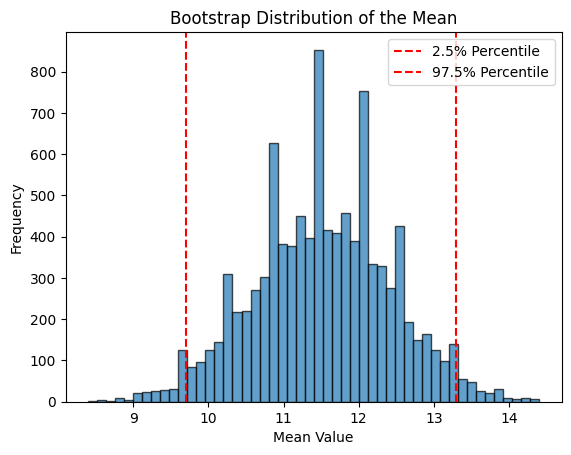

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Original dataset
data = np.array([10, 12, 9, 11, 15, 14, 13, 8, 7, 16])

# Define number of bootstrap samples
n_bootstrap = 10000

# Create an array to store bootstrap sample means
bootstrap_means = np.zeros(n_bootstrap)

# Perform bootstrap resampling
for i in range(n_bootstrap):
    # Randomly sample with replacement from the original data
    bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
    
    # Calculate the mean of the bootstrap sample
    bootstrap_means[i] = np.mean(bootstrap_sample)

# Calculate the 95% confidence interval
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

# Output results
print(f"Original Mean: {np.mean(data)}")
print(f"Bootstrap 95% Confidence Interval: ({lower_bound}, {upper_bound})")

# Visualize the bootstrap distribution
plt.hist(bootstrap_means, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(lower_bound, color='red', linestyle='--', label="2.5% Percentile")
plt.axvline(upper_bound, color='red', linestyle='--', label="97.5% Percentile")
plt.title("Bootstrap Distribution of the Mean")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:
# . Permutation Resampling
# Permutation resampling (also known as randomization resampling) is used to test hypotheses, particularly when comparing two groups. It involves repeatedly randomizing or shuffling the data between the groups to create a distribution of the test statistic under the null hypothesis (i.e., assuming no effect or difference between the groups).

# Key Concepts:

# Without replacement: Unlike bootstrap, permutation resampling does not sample with replacement.
# Null hypothesis testing: You randomly shuffle or permute the data to simulate what would happen under the null hypothesis (e.g., that two groups are identical).
# Example: Permutation Test to Compare Two Means

# Suppose we want to test whether the means of two groups are significantly different. We have two groups, Group A and Group B, and we want to test if their means differ using a permutation test.

In [4]:
import numpy as np

# Example data
group_a = np.array([10, 12, 9, 11, 15, 14, 13, 8, 7, 16])
group_b = np.array([20, 22, 19, 18, 21, 23, 17, 16, 25, 24])

# Observed difference in means
observed_diff = np.abs(np.mean(group_a) - np.mean(group_b))
print(f"Observed Difference in Means: {observed_diff}")

# Combine the data
combined_data = np.concatenate([group_a, group_b])

# Perform permutation test
n_permutations = 10000
permuted_diffs = np.zeros(n_permutations)

for i in range(n_permutations):
    # Shuffle the combined data
    np.random.shuffle(combined_data)
    
    # Split the shuffled data back into two groups
    permuted_group_a = combined_data[:len(group_a)]
    permuted_group_b = combined_data[len(group_a):]
    
    # Calculate the difference in means
    permuted_diffs[i] = np.abs(np.mean(permuted_group_a) - np.mean(permuted_group_b))

# Calculate p-value: proportion of permuted differences greater than or equal to observed difference
p_value = np.mean(permuted_diffs >= observed_diff)

print(f"P-value: {p_value}")

# Decision based on p-value
if p_value < 0.05:
    print("Reject the null hypothesis. The means of Group A and Group B are significantly different.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference between the means.")


Observed Difference in Means: 9.0
P-value: 0.0
Reject the null hypothesis. The means of Group A and Group B are significantly different.


In [5]:
import numpy as np
import scipy.stats as stats

# Simulated data
# Group A (Control Group): 1000 visitors, 150 conversions
group_a_visitors = 1000
group_a_conversions = 150

# Group B (Variant Group): 1000 visitors, 180 conversions
group_b_visitors = 1000
group_b_conversions = 180

# Conversion rates
group_a_conversion_rate = group_a_conversions / group_a_visitors
group_b_conversion_rate = group_b_conversions / group_b_visitors

print(f"Group A Conversion Rate: {group_a_conversion_rate:.2f}")
print(f"Group B Conversion Rate: {group_b_conversion_rate:.2f}")

# Perform a Z-test for proportions
# H₀: pA = pB
# Z = (pA - pB) / sqrt(p*(1-p)*(1/nA + 1/nB))
# where p is the pooled proportion
p_pooled = (group_a_conversions + group_b_conversions) / (group_a_visitors + group_b_visitors)
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/group_a_visitors + 1/group_b_visitors))
z_score = (group_a_conversion_rate - group_b_conversion_rate) / se

# Calculate the p-value for the z-test
p_value = stats.norm.cdf(z_score)

print(f"Z-Score: {z_score:.3f}")
print(f"P-value: {p_value:.3f}")

# Decision based on p-value (significance level = 0.05)
if p_value < 0.05:
    print("Reject the null hypothesis. Group B's conversion rate is significantly higher.")
else:
    print("Fail to reject the null hypothesis. No significant difference in conversion rates.")


Group A Conversion Rate: 0.15
Group B Conversion Rate: 0.18
Z-Score: -1.807
P-value: 0.035
Reject the null hypothesis. Group B's conversion rate is significantly higher.


In [ ]:
# # P-value in Statistics
# # The p-value is a fundamental concept in hypothesis testing that helps you determine 
# the significance of your results. It is used to quantify the evidence against the null hypothesis in statistical tests.

# # Key Concepts:

# # Null Hypothesis (H₀): This is a default assumption that there is no effect, 
# no difference, or no relationship between the variables you're testing. For example, in an A/B test, the null hypothesis might
# be that there is no difference in conversion rates between the two groups.
# # Alternative Hypothesis (H₁): This is the hypothesis that contradicts the null hypothesis, 
# suggesting that there is a difference or effect.
# # Definition:

# # The p-value is the probability of obtaining a result at least as extreme as the one observed,
#     assuming that the null hypothesis is true. It essentially tells you how likely it is to observe the data you have (or something more extreme) if the null hypothesis were true.

# # Interpreting P-value:
# # Low p-value (≤ 0.05): If the p-value is small (usually less than or equal to 0.05),
# it indicates strong evidence against the null hypothesis. This means the observed result
# is unlikely to have occurred under the assumption of the null hypothesis, so you may reject 
# the null hypothesis and conclude that there is a statistically significant effect or difference.
# # High p-value (> 0.05): If the p-value is large, it suggests weak evidence against the null hypothesis. 
# This means the observed result is likely to have occurred by chance, so you fail to reject the null hypothesis and 
# conclude that there is no significant effect or difference.

In [6]:
import numpy as np
import scipy.stats as stats

# Simulated data for the two groups
group_a_visitors = 1000
group_a_conversions = 150
group_b_visitors = 1000
group_b_conversions = 180

# Conversion rates
group_a_conversion_rate = group_a_conversions / group_a_visitors
group_b_conversion_rate = group_b_conversions / group_b_visitors

# Pooled proportion
p_pooled = (group_a_conversions + group_b_conversions) / (group_a_visitors + group_b_visitors)

# Standard error of the difference
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/group_a_visitors + 1/group_b_visitors))

# Z-score for the difference between the conversion rates
z_score = (group_a_conversion_rate - group_b_conversion_rate) / se

# Calculate the p-value (two-tailed test)
p_value = stats.norm.cdf(z_score)

# Print results
print(f"Z-score: {z_score:.3f}")
print(f"P-value: {p_value:.3f}")

# Decision based on p-value (alpha = 0.05)
if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis. No significant difference between the groups.")


Z-score: -1.807
P-value: 0.035
Reject the null hypothesis. There is a significant difference between the groups.


In [ ]:
# T-Test in Statistics
# A T-test is a statistical test used to determine whether there is a significant difference between the means of two groups. It's commonly used when the data follows a normal distribution and when sample sizes are small (typically under 30). The T-test can be used for both paired and unpaired data.

# There are three main types of T-tests:

# One-Sample T-Test: Compares the mean of a sample to a known value (often the population mean).
# Independent Two-Sample T-Test: Compares the means of two independent groups (unpaired).
# Paired Sample T-Test: Compares the means of two related groups (paired data).
# Let's explore each of these tests, focusing on the independent two-sample t-test, which is one of the most commonly used.

In [7]:
import numpy as np
from scipy import stats

# Simulated test scores for two groups
group_a_scores = np.array([88, 92, 95, 89, 91, 87, 93, 94, 90, 92])  # Group A (Method A)
group_b_scores = np.array([78, 80, 82, 84, 79, 77, 75, 76, 81, 79])  # Group B (Method B)

# Perform an independent t-test
t_stat, p_value = stats.ttest_ind(group_a_scores, group_b_scores)

# Output results
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the result based on p-value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the groups.")


T-statistic: 9.992
P-value: 0.000
Reject the null hypothesis: There is a significant difference between the groups.


In [ ]:
# Multiple Testing in Statistics
# Multiple testing refers to the situation in statistical analysis where multiple hypothesis tests 
# are conducted simultaneously. As the number of tests increases, the chance of obtaining 
# at least one false positive (Type I error) increases as well, even if the null hypothesis is true in all tests.
# This is a problem commonly encountered in experiments involving multiple comparisons or tests on several variables.

# For example, in clinical trials, researchers might test the effect of a new drug on several different outcomes
# (e.g., blood pressure, heart rate, weight loss), which increases the likelihood of finding a false positive result for
# one of the outcomes simply by chance.

In [ ]:
# Degrees of Freedom (df) in Statistics
# Degrees of freedom (df) is a concept used in statistical analysis to describe the number of independent pieces of information available to estimate a parameter or compute a statistic. It represents the number of values that are free to vary when calculating a statistic, subject to any constraints that may apply.

# The concept of degrees of freedom is crucial in many statistical tests, including the t-test, chi-square test, ANOVA, and in calculating the variance and standard deviation. It helps in understanding the variability in a sample and is necessary to determine the appropriate distributions (like t-distribution, chi-square distribution) for hypothesis testing.

# General Formula for Degrees of Freedom
# In many cases, the degrees of freedom (
# d
# f
# df) can be calculated as:

# d
# f
# =
# n
# −
# k
# df=n−k
# Where:

# n
# n is the number of observations or sample size.
# k
# k is the number of constraints or parameters being estimated (e.g., the number of groups or the number of parameters in the model).
# Examples of Degrees of Freedom in Different Statistical Tests
# 1. Degrees of Freedom for Variance and Standard Deviation

# When you estimate the variance or standard deviation of a sample, the degrees of freedom is calculated as:

# d
# f
# =
# n
# −
# 1
# df=n−1
# Where 
# n
# n is the sample size.

# The reason we use 
# n
# −
# 1
# n−1 instead of 
# n
# n is to correct for bias. This adjustment is called Bessel's correction. Using 
# n
# −
# 1
# n−1 gives an unbiased estimate of the population variance from a sample.
# Example:

# If you have a sample of 5 data points: 
# [
# 5
# ,
# 6
# ,
# 8
# ,
# 7
# ,
# 9
# ]
# [5,6,8,7,9]

# Calculate the mean: 
# mean
# =
# 5
# +
# 6
# +
# 8
# +
# 7
# +
# 9
# 5
# =
# 7
# mean= 
# 5
# 5+6+8+7+9
# ​	
#  =7
# Compute the variance:
# variance
# =
# (
# 5
# −
# 7
# )
# 2
# +
# (
# 6
# −
# 7
# )
# 2
# +
# (
# 8
# −
# 7
# )
# 2
# +
# (
# 7
# −
# 7
# )
# 2
# +
# (
# 9
# −
# 7
# )
# 2
# 5
# −
# 1
# =
# 4
# +
# 1
# +
# 1
# +
# 0
# +
# 4
# 4
# =
# 2.5
# variance= 
# 5−1
# (5−7) 
# 2
#  +(6−7) 
# 2
#  +(8−7) 
# 2
#  +(7−7) 
# 2
#  +(9−7) 
# 2
 
# ​	
#  = 
# 4
# 4+1+1+0+4
# ​	
#  =2.5
# Thus, the degrees of freedom for the variance is 4.

# 2. Degrees of Freedom for a t-test (Independent Two-Sample t-test)

# For an independent two-sample t-test, the degrees of freedom is calculated as:

# d
# f
# =
# n
# 1
# +
# n
# 2
# −
# 2
# df=n 
# 1
# ​	
#  +n 
# 2
# ​	
#  −2
# Where:

# n
# 1
# n 
# 1
# ​	
#   is the sample size of the first group.
# n
# 2
# n 
# 2
# ​	
#   is the sample size of the second group.
# Example:

# If Group 1 has 10 samples and Group 2 has 12 samples:

# d
# f
# =
# 10
# +
# 12
# −
# 2
# =
# 20
# df=10+12−2=20
# So, the degrees of freedom for the t-test would be 20.

# 3. Degrees of Freedom for Chi-Square Test

# In a Chi-Square Test, the degrees of freedom depends on the type of test you're performing. For example, for a Goodness of Fit Test, the degrees of freedom is:

# d
# f
# =
# k
# −
# 1
# df=k−1
# Where 
# k
# k is the number of categories in the distribution.

# For a Chi-Square Test of Independence, the degrees of freedom is:

# d
# f
# =
# (
# r
# −
# 1
# )
# (
# c
# −
# 1
# )
# df=(r−1)(c−1)
# Where:

# r
# r is the number of rows in the contingency table.
# c
# c is the number of columns in the contingency table.
# Example:

# For a contingency table with 3 rows and 4 columns:

# d
# f
# =
# (
# 3
# −
# 1
# )
# (
# 4
# −
# 1
# )
# =
# 2
# ×
# 3
# =
# 6
# df=(3−1)(4−1)=2×3=6
# Thus, the degrees of freedom would be 6.

# 4. Degrees of Freedom in ANOVA (Analysis of Variance)

# In ANOVA, the degrees of freedom are split into several components:

# Between-group degrees of freedom: 
# d
# f
# b
# e
# t
# w
# e
# e
# n
# =
# k
# −
# 1
# df 
# between
# ​	
#  =k−1, where 
# k
# k is the number of groups.
# Within-group degrees of freedom: 
# d
# f
# w
# i
# t
# h
# i
# n
# =
# n
# −
# k
# df 
# within
# ​	
#  =n−k, where 
# n
# n is the total sample size and 
# k
# k is the number of groups.
# Example:

# If there are 4 groups and a total of 40 samples:

# Between-group degrees of freedom: 
# d
# f
# b
# e
# t
# w
# e
# e
# n
# =
# 4
# −
# 1
# =
# 3
# df 
# between
# ​	
#  =4−1=3
# Within-group degrees of freedom: 
# d
# f
# w
# i
# t
# h
# i
# n
# =
# 40
# −
# 4
# =
# 36
# df 
# within
# ​	
#  =40−4=36
# 5. Degrees of Freedom for Linear Regression

# In linear regression, the degrees of freedom can be calculated for different components:

# Degrees of freedom for the model: 
# d
# f
# model
# =
# p
# df 
# model
# ​	
#  =p, where 
# p
# p is the number of predictors (including the intercept).
# Degrees of freedom for the residuals: 
# d
# f
# residual
# =
# n
# −
# p
# −
# 1
# df 
# residual
# ​	
#  =n−p−1, where 
# n
# n is the number of data points.
# Example:

# If you have 100 data points and 3 predictors:

# Degrees of freedom for the model: 
# d
# f
# model
# =
# 3
# df 
# model
# ​	
#  =3
# Degrees of freedom for the residuals: 
# d
# f
# residual
# =
# 100
# −
# 3
# −
# 1
# =
# 96
# df 
# residual
# ​	
#  =100−3−1=96
# Importance of Degrees of Freedom
# Degrees of freedom are important because they:

# Affect the distribution used in hypothesis testing. For example, the t-distribution has different shapes depending on the degrees of freedom, and as the degrees of freedom increase, the t-distribution becomes closer to the normal distribution.
# Determine the critical values for hypothesis testing. For example, in a t-test or chi-square test, the degrees of freedom determine the critical value at a certain confidence level (e.g., 95% or 99%).
# Influence statistical power. Fewer degrees of freedom mean less power to detect a true effect, as the test may be less precise.
# Python Example: Calculating Degrees of Freedom for t-Test
# Let's use Python to calculate the degrees of freedom for an independent two-sample t-test.



In [8]:
import numpy as np
from scipy import stats

# Sample data for two groups
group_1 = [23, 45, 56, 67, 89, 45, 67]
group_2 = [34, 56, 67, 45, 34, 23, 56, 45]

# Perform an independent two-sample t-test
t_stat, p_value = stats.ttest_ind(group_1, group_2)

# Calculate degrees of freedom
n_1 = len(group_1)
n_2 = len(group_2)

df = n_1 + n_2 - 2  # Degrees of freedom for two-sample t-test

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {df}")

T-statistic: 1.195
P-value: 0.254
Degrees of Freedom: 13


In [ ]:
#Hot encoding
#Multicolinearity

In [ ]:
# NOVA (Analysis of Variance)
# ANOVA (Analysis of Variance) is a statistical method used to analyze the differences among group means and determine whether any of those differences are statistically significant. It tests the null hypothesis that all group means are equal. If the p-value from the ANOVA test is small enough (typically less than 0.05), it suggests that at least one group mean is different from the others.

# Key Concepts in ANOVA:
# Null Hypothesis (H₀):
# All group means are equal. There is no significant difference between the groups.
# Alternative Hypothesis (H₁):
# At least one group mean is different from the others.
# Between-group variance:
# Variability due to the differences between the groups.
# Within-group variance:
# Variability due to differences within each group.
# F-statistic:
# The test statistic used in ANOVA is the F-statistic, which is the ratio of the between-group variance to the within-group variance.
# F
# =
# Between-group variance
# Within-group variance
# F= 
# Within-group variance
# Between-group variance
# ​	
 
# A large F-statistic suggests that there is more variation between the groups than within the groups, which would lead to rejecting the null hypothesis.
# Types of ANOVA
# One-Way ANOVA:
# Used when you have one independent variable (factor) and you want to compare more than two groups.
# For example, comparing the average scores of three different teaching methods.
# Two-Way ANOVA:
# Used when you have two independent variables, and you want to analyze the effect of both on a dependent variable, as well as their interaction.
# For example, studying the effects of both age group and gender on test scores.
# Repeated Measures ANOVA:
# Used when the same subjects are measured multiple times under different conditions or over time.

In [ ]:
# Assumptions of ANOVA:
# For the results of ANOVA to be valid, the following assumptions should be met:

# Independence of observations: The data collected from different groups must be independent.
# Normality: The data in each group should be approximately normally distributed.
# Homogeneity of variances (Homoscedasticity): The variance within each group should be approximately equal across all groups.
# If these assumptions are violated, alternative statistical tests (like Kruskal-Wallis test or Welch’s ANOVA) might be considered.

# Steps for Conducting ANOVA:
# State the hypotheses:
# Null Hypothesis (H₀): All group means are equal.
# Alternative Hypothesis (H₁): At least one group mean is different.
# Choose a significance level (
# α
# α):
# Typically, 
# α
# =
# 0.05
# α=0.05 (5%).
# Calculate the F-statistic:
# Divide the between-group variance by the within-group variance.
# Compare the p-value with 
# α
# α:
# If 
# p
# ≤
# α
# p≤α, reject the null hypothesis.
# If 
# p
# >
# α
# p>α, fail to reject the null hypothesis.

In [9]:
import numpy as np
import scipy.stats as stats

# Sample data: Scores of 3 groups (A, B, C)
group_A = [23, 21, 19, 25, 27]
group_B = [30, 31, 29, 28, 32]
group_C = [40, 42, 41, 43, 39]

# Perform One-Way ANOVA
f_statistic, p_value = stats.f_oneway(group_A, group_B, group_C)

print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: At least one group mean is different.")
else:
    print("Fail to reject the null hypothesis: No significant difference between groups.")


F-statistic: 82.333
P-value: 0.000
Reject the null hypothesis: At least one group mean is different.


In [10]:
#Fsatistics